<!-- ![Accident Plot](banner.jpeg) -->
<img src="banner.jpeg" width="1200">

<!--# Project Title-->
# Exploring Weather, Road, and Time Factors in US Traffic Accidents

## Overview

Short project description. Your bottom line up front (BLUF) insights.

Task: Analyze the US Accidents dataset to identify patterns, trends, and factors contributing to accidents. Based on your comprehensive analysis, you'll provide three data-driven insights that the DOT could utilize to reduce traffic accidents and improve road safety.

## Potential Areas of Analysis

#### Spatial and Temporal Patterns:
Consider examining when and where accidents most frequently occur. You might explore patterns by time of day, day of week, season, and geographic location. This type of analysis could potentially reveal critical hotspots and time periods requiring intervention.

#### Environmental Factors:
You could investigate how weather conditions correlate with accident rates. Consider analyzing how visibility, precipitation, temperature, and other environmental variables might affect driver behavior and road conditions.

#### Infrastructure Considerations:
One possible avenue is to identify specific road features associated with accident severity. This might include road design, signage, lighting, or other infrastructural elements that could contribute to or mitigate accident risk.

#### Urban vs. Rural Comparison:
You may want to compare accident patterns between urban and rural settings. These different environments likely present distinct challenges and risk factors that might require tailored safety approaches.

## Business Understanding

Text here

This explains why the project matters in the real world.

Include:

- Business scenario (traffic safety)
- Project motivation
- Analytical questions
- Stakeholders
- Expected benefits

Examples of content:

#### Problem

Traffic accidents cause significant injuries, fatalities, and economic losses each year.

#### Questions

- Are accidents more severe during nighttime?
- Does precipitation increase accident severity?
- Which road features correlate with higher accident risk?

#### Stakeholders

- Transportation departments
- Urban planners
- Traffic safety agencies

## Data Understanding

Text here

This section explains what data you have and what it contains.
Include:

#### Tasks:
- Load dataset &#x2705;
- Show dataset size (df.shape) &#x2705;
- Inspect structure (df.info()) &#x2705;
- Describe variables (df.describe()) &#x2705;
- Document variables and meaning
- Identify categorical vs numerical columns &#x2705;
- Explore missing values &#x2705;
- Initial visualizations &#x2705;

#### Example topics:
- Number of rows and columns
- Types of variables (numeric, categorical, boolean)
- Key columns such as Severity, Temperature, Visibility
- Missing data patterns


In [1]:
# Load relevant imports here

# Data Analysis
import pandas as pd
#import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
#scipyLinks to an external site.
#statsmodelsLinks to an external site.

In [2]:
# Load the dataset (raw)
df_raw = pd.read_csv("US_Accidents_March23.csv")

# Keep working copy for cleaning and feature engineering (later)
df = df_raw.copy()


In [3]:
# Inspect first five rows
pd.set_option('display.max_columns', None)
df.head()

#pd.reset_option('display.max_columns')

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
# Describe variables 

df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [5]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [6]:
# Show dataset size

df.shape

(7728394, 46)

In [7]:
# Check all column headers - their meaning, type and typical values
#
# Source Data Description: https://smoosavi.org/datasets/us_accidents
# Longitude/ Latitude Map of the USA: https://springwatertrails.org/2015/03/gps/
#
#  0 - ID - object - Identifier A-x where x is accident number (corresponds to each row in dataset)
#  1 - Source - object - Source of raw accident data; possible values are Source1, Source2 and Source3
#  2 - Severity - int64 - Shows the severity of the accident, a number between 1 and 4, where 1 indicates the least impact on traffic (i.e., short delay as a result of the accident) and 4 indicates a significant impact on traffic (i.e., long delay).
#  3 - Start_Time - object - Shows start time of the accident in local time zone; format is: YYYY--MM-DD HH:MM:SS (24 h format).
#  4 - End_Time - object - Shows end time of the accident in local time zone. End time here refers to when the impact of accident on traffic flow was dismissed.
#  5 - Start_Lat - float64 - Shows latitude in GPS coordinate of the start point.
#  6 - Start_Lng - float64 - Shows longitude in GPS coordinate of the start point.
#  7 - End_Lat - float64 - Shows latitude in GPS coordinate of the end point.
#  8 - End_Lng - float64 - Shows longitude in GPS coordinate of the end point.
#  9 - Distance(mi) - float64 - The length of the road extent affected by the accident.
# 10 - Desciption - object - Shows natural language description of the accident.
# 11 - Street - object - Shows the street name in address field.
# 12 - City - object - Shows the city in address field.
# 13 - County - object - Shows the county in address field.
# 14 - State - object - Shows the state in address field.
# 15 - Zipcode - object - Shows the zipcode in address field.
# 16 - Country - object - Shows the country in address field.
# 17 - Timezone - object - Shows timezone based on the location of the accident (eastern, central, etc.).	
# 18 - Airport_Code - object - Denotes an airport-based weather station which is the closest one to location of the accident
# 19 - Weather_Timestamp - object - Shows the time-stamp of weather observation record (in local time). Format is: YYYY--MM-DD HH:MM:SS (24 h format).
# 20 - Temperature(F) - float64 - Shows the temperature (in Fahrenheit).
# 21 - Wind_Chill(F) - float64 - Shows the wind chill (in Fahrenheit).
# 22 - Humidity(%) - float64 - Shows the humidity (in percentage).
# 23 - Pressure(in) - float64 - Shows the air pressure (in inches).
# 24 - Visibility(mi) - float64 - Shows visibility (in miles).
# 35 - Wind_Direction - object - Shows wind direction.
# 36 - Wind_Speed(mph) - float64 - Shows wind speed (in miles per hour). This has NaN when it is calm (no wind).
# 27 - Precipitation(in) - float64 - Shows precipitation amount in inches, if there is any.
# 28 - Weather_Condition - object - Shows the weather condition (rain, snow, thunderstorm, fog, etc.)
# 29 - Amenity - bool - A POI annotation which indicates presence of amenity in a nearby location.
# 30 - Bump - bool - A POI annotation which indicates presence of speed bump or hump in a nearby location.
# 31 - Crossing - bool - A POI annotation which indicates presence of crossing in a nearby location.
# 32 - Give_Way - bool - A POI annotation which indicates presence of give_way in a nearby location.
# 33 - Junction - bool - A POI annotation which indicates presence of junction in a nearby location.
# 34 - No_Exit - bool - A POI annotation which indicates presence of no_exit in a nearby location.
# 35 - Railway - bool - A POI annotation which indicates presence of railway in a nearby location.
# 36 - Roundabout - bool - A POI annotation which indicates presence of roundabout in a nearby location.
# 37 - Station - bool - A POI annotation which indicates presence of station in a nearby location.
# 38 - Stop - bool - A POI annotation which indicates presence of stop in a nearby location.
# 39 - Traffic_Calming - bool - A POI annotation which indicates presence of traffic_calming in a nearby location.
# 40 - Traffic_Signal - bool - A POI annotation which indicates presence of traffic_signal in a nearby loction.
# 41 - Turning_Loop - bool - A POI annotation which indicates presence of turning_loop in a nearby location.
# 42 - Sunrise_Sunset - object - Shows the period of day (i.e. day or night) based on sunrise/sunset.
# 43 - Civil_Twilight - object - Shows the period of day (i.e. day or night) based on civil twilight.
# 44 - Nautical_Twilight - object - Shows the period of day (i.e. day or night) based on nautical twilight.
# 45 - Astronomical_Twilight - object - Shows the period of day (i.e. day or night) based on astronomical twilight.


#df["ID"].head()
#df.ID.head()
#df["Source"].unique()
#df["Severity"].unique()
#df["Start_Time"].info
#df["End_Time"].info
#df["Start_Lat"].info
#df["Start_Lng"].info
#df["Distance(mi)"].describe()
#print(df["Description"])
#df[["Street", "City", "County", "State", "Zipcode", "Country"]].head()
#df["Country"].unique()
#df["Street"].nunique() # 336,306
#df["City"].nunique() # 13,678
#df["County"].nunique() # 1,871
#df["State"].nunique() # 49
#df["Zipcode"].nunique() # 825,094
#df["Country"].nunique() # 1 i.e. USA; can eliminate that because it adds no value.
#df["Timezone"].unique() # There are 4 Time Zones i.e. Eastern, Central, Mountain, and Pacific, and there are instances of NaN.
#df["Airport_Code"].nunique() # 2,045
#df["Weather_Timestamp"].info
#df["Temperature(F)"].head()
#df[["Temperature(F)","Wind_Chill(F)","Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Direction"]]
#df["Wind_Direction"].unique() # needs cleaning up because of NaN.
#df[["Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)"]]
#df["Weather_Condition"].head()
#df["Amenity"].value_counts() # 96334 True
#df["Bump"].value_counts() # 3,514 True
#df["Crossing"].value_counts() # 873,763 True
#df["Give_Way"].value_counts() # 36,582 True
#df["Give_Way"].value_counts() # 36,582 True
#df["No_Exit"].value_counts() # 19,545 True
#df["Railway"].value_counts() # 66,979 True
#df["Roundabout"].value_counts() # 249 True
#df["Station"].value_counts() # 201,901 True
#df["Stop"].value_counts() # 214,371 True
#df["Traffic_Calming"].value_counts() # 7,598 True
#df["Traffic_Signal"].value_counts() # 1,143,772 True
#df["Turning_Loop"].value_counts() # 0 True (all are False)
#df[["Sunrise_Sunset","Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]].head()
#df["Sunrise_Sunset"].value_counts() # only 2 values: 5,334,553 Day; 2,370,595 Night
#df["Civil_Twilight"].value_counts() # only 2 values: 5,695,619 Day; 2,009,529 Night
#df["Nautical_Twilight"].value_counts() # only 2 valuess: 6,076,156 Day; 1,628,992 Night
#df["Astronomical_Twilight"].value_counts() # only 2 values: 6,377,548 Day; 1,327,600 Night

#df["Street"].isna().sum()


In [8]:
# Identify categorical vs numerical columns

# Categorical / object / boolean columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
ID: 7728394 unique values
Source: 3 unique values
Start_Time: 6131796 unique values
End_Time: 6705355 unique values
Description: 3761578 unique values
Street: 336306 unique values
City: 13678 unique values
County: 1871 unique values
State: 49 unique values
Zipcode: 825094 unique values
Country: 1 unique values
Timezone: 4 unique values
Airport_Code: 2045 unique values
Weather_Timestamp: 941331 unique values
Wind_Direction: 24 unique values
Weather_Condition: 144 unique values
Amenity: 2 unique values
Bump: 2 unique values
C

End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Nautical_Twilight          23246
Civil_Twilight             23246
Sunrise_Sunset             23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
dtype: int64


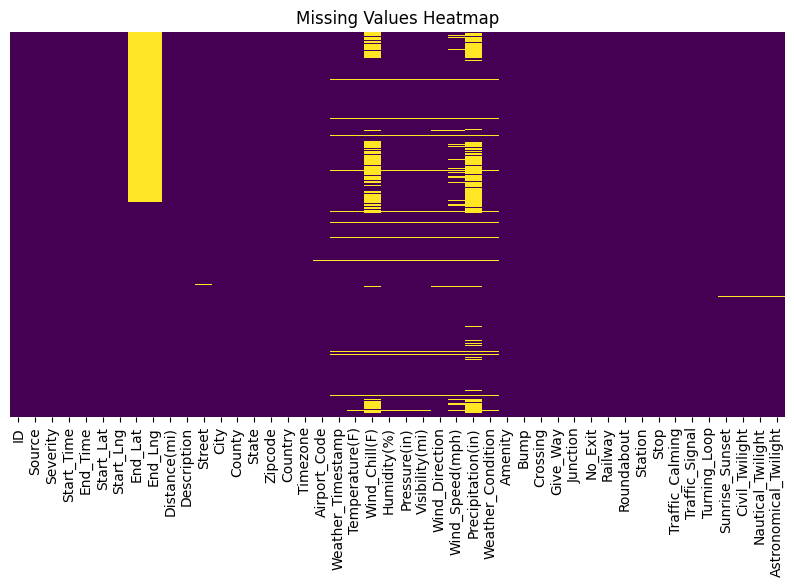

In [9]:
# Explore missing values

missing_counts = df.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


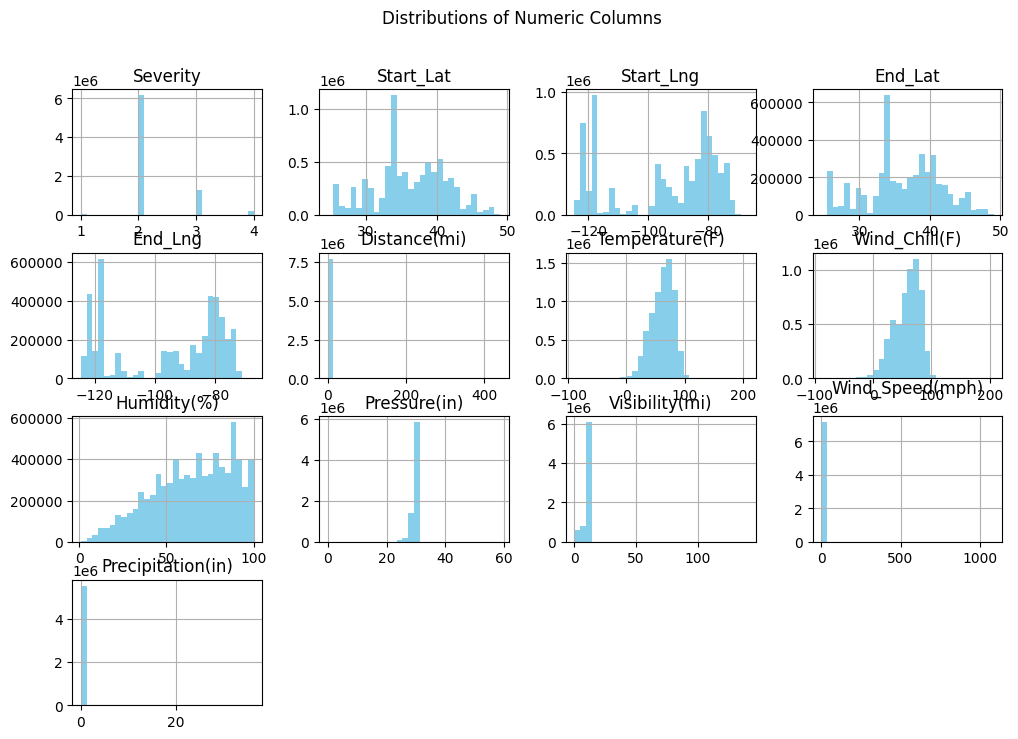

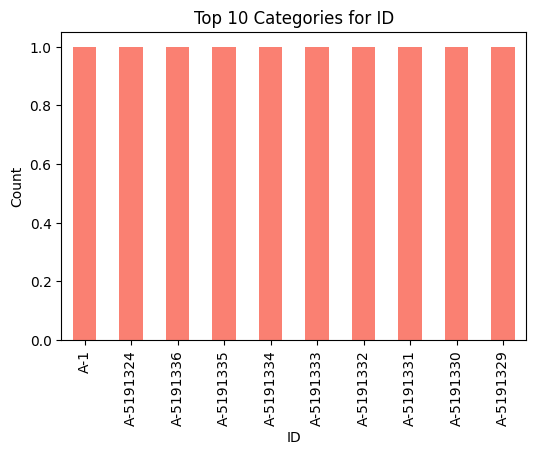

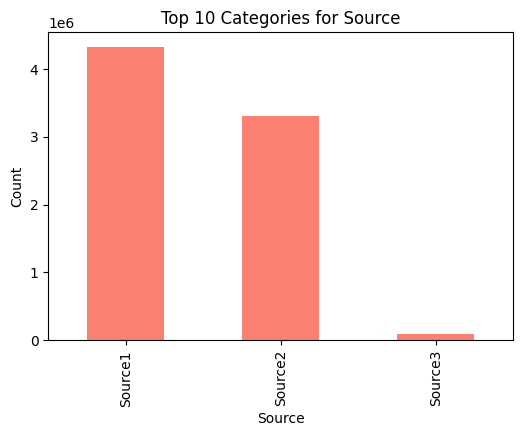

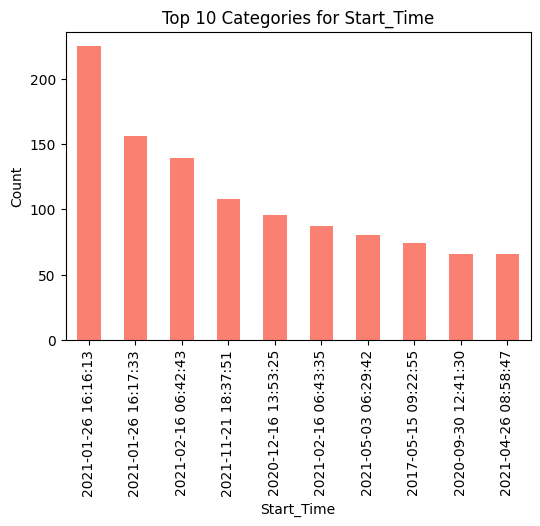

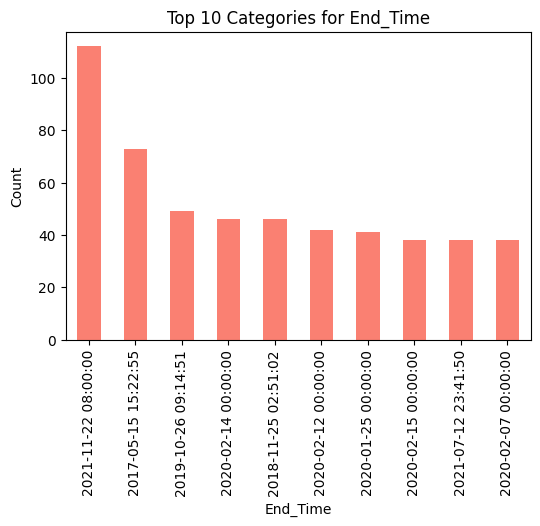

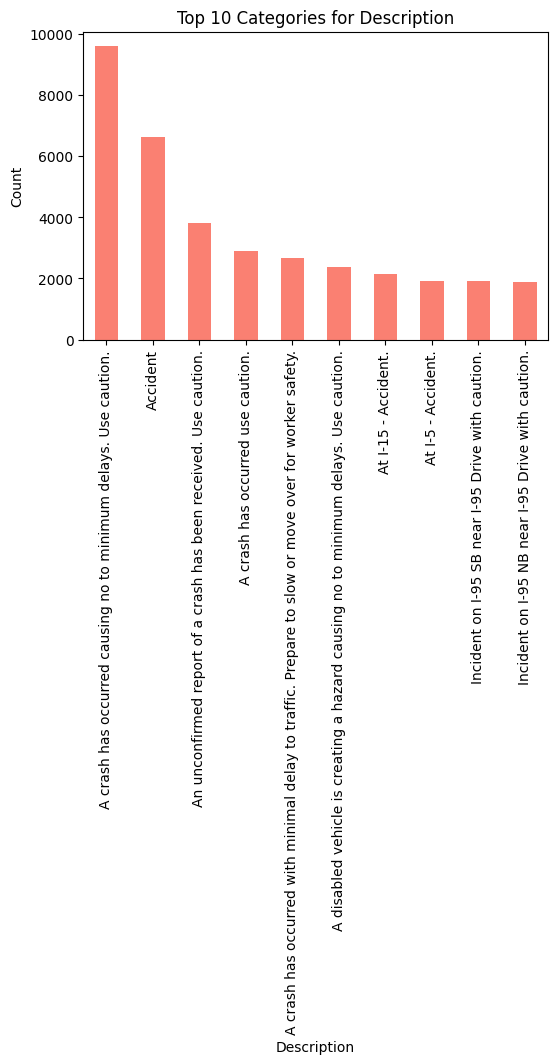

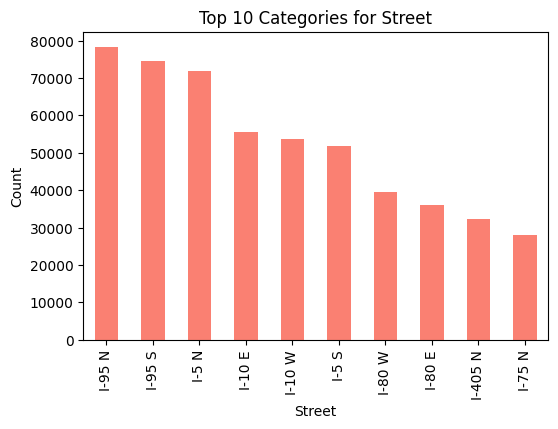

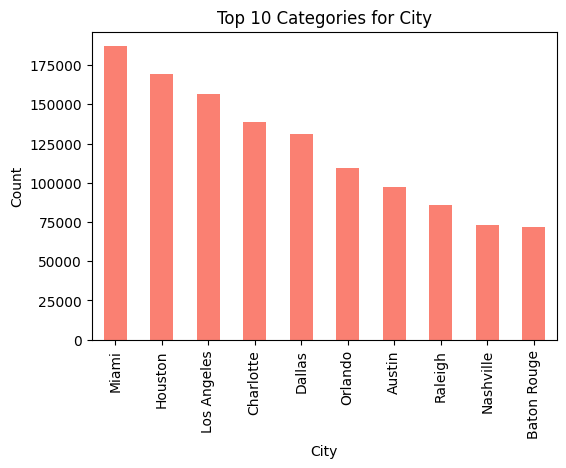

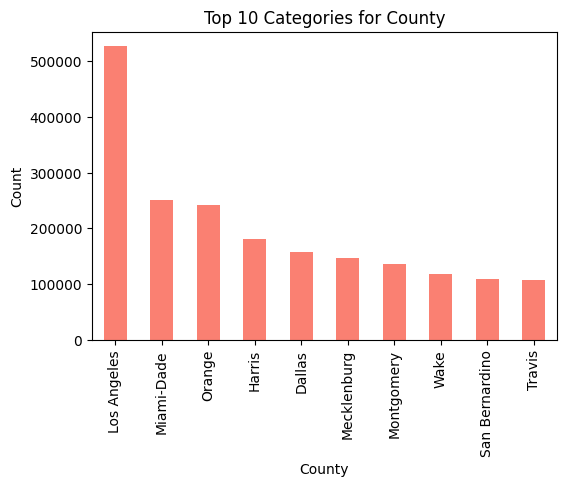

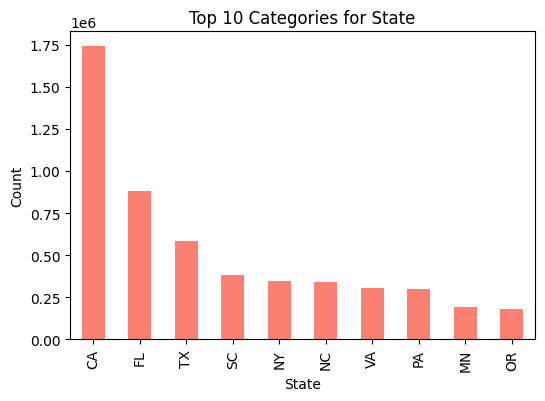

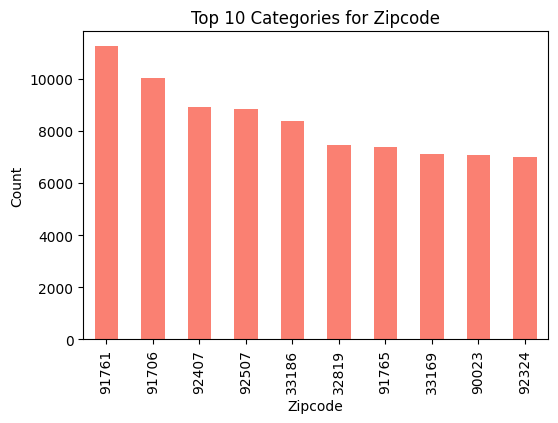

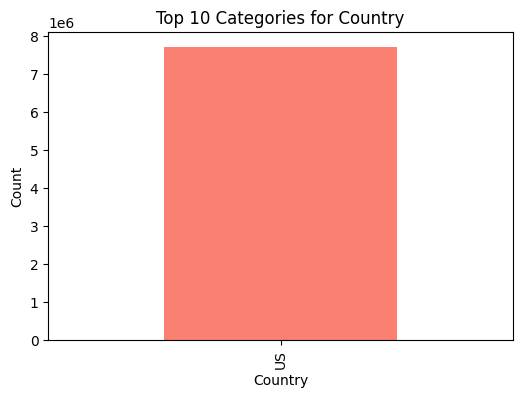

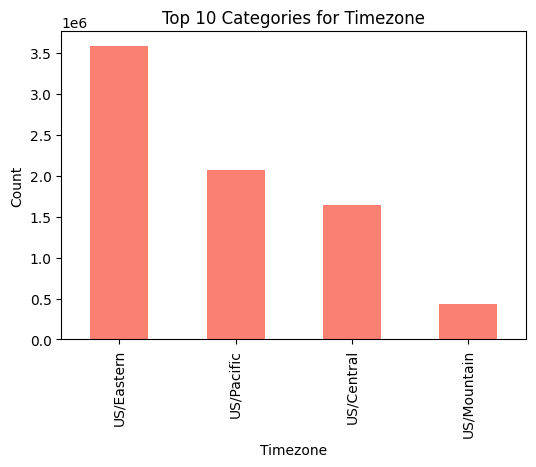

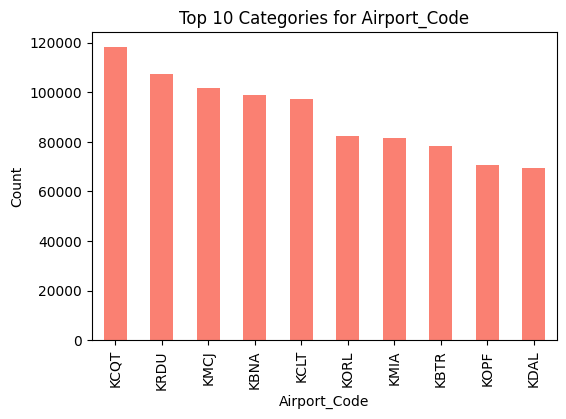

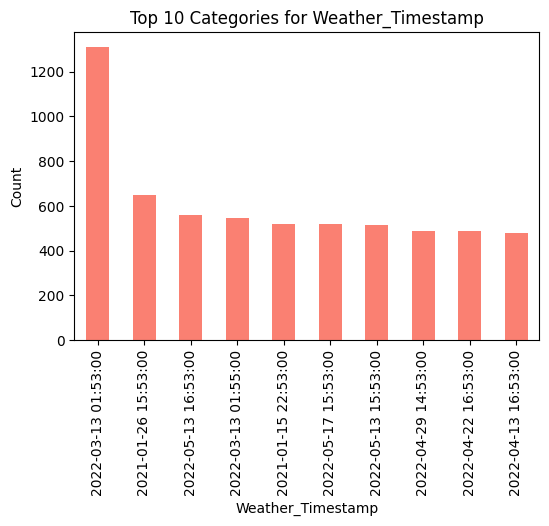

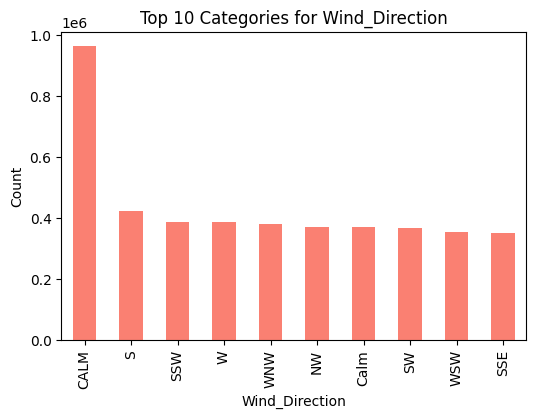

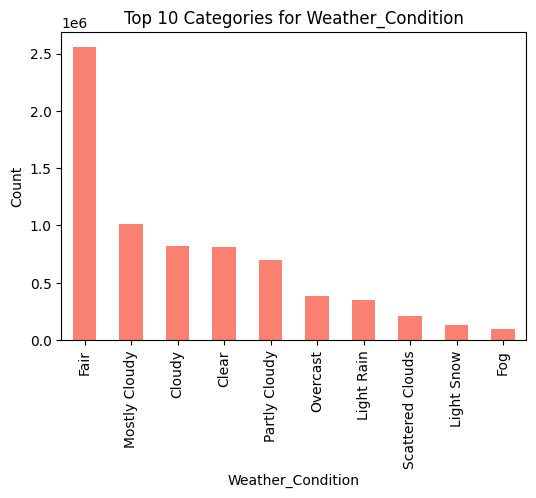

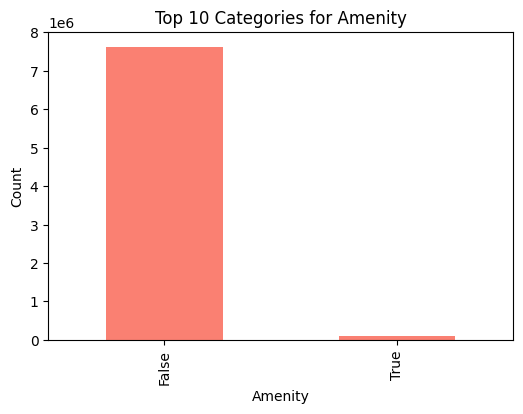

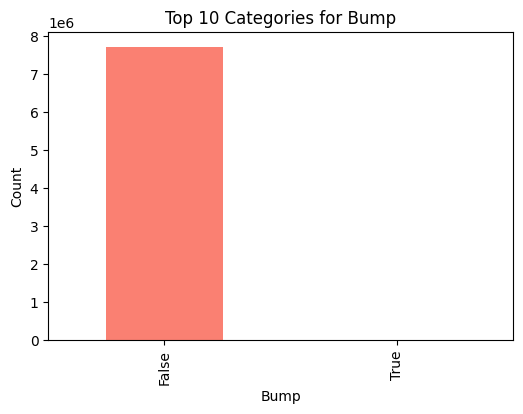

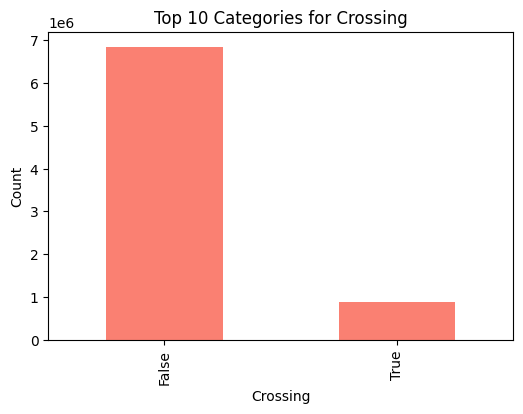

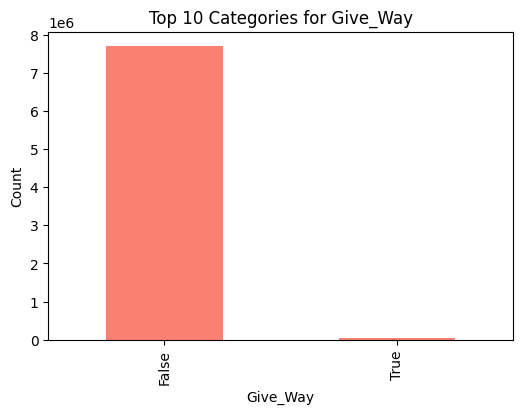

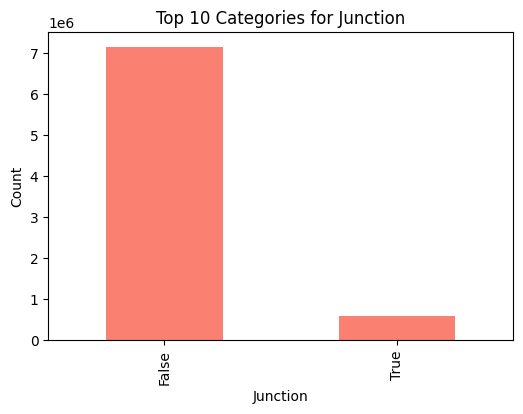

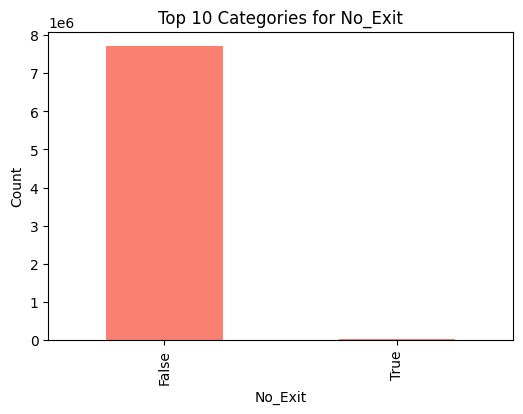

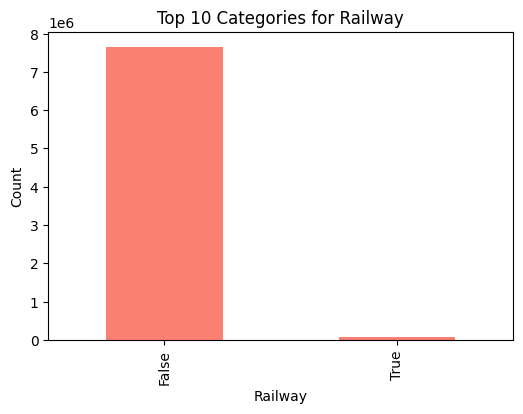

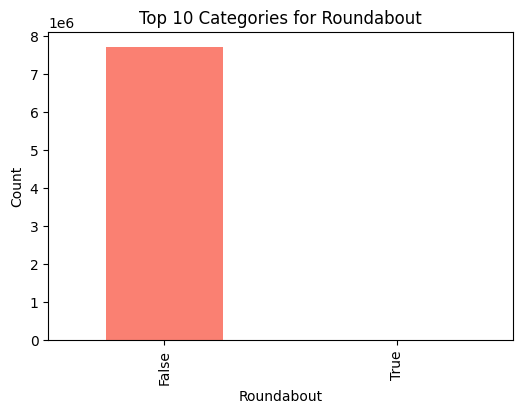

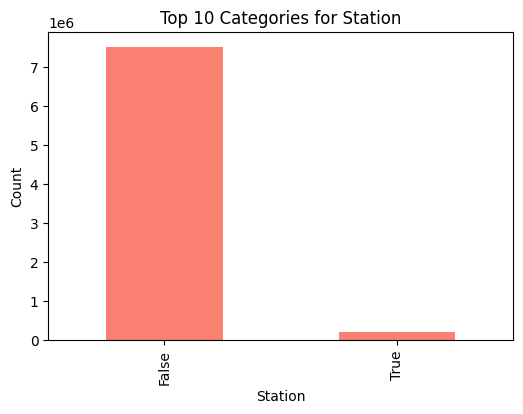

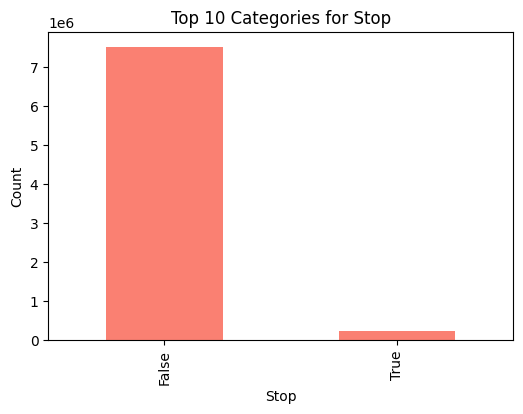

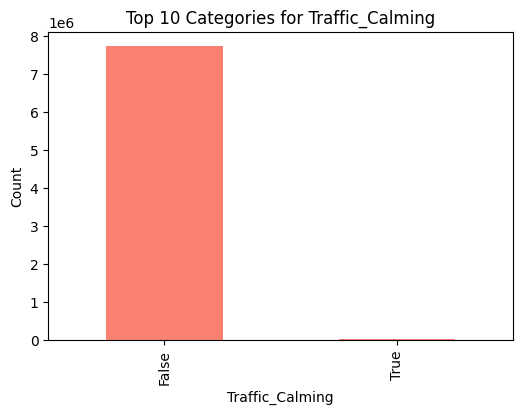

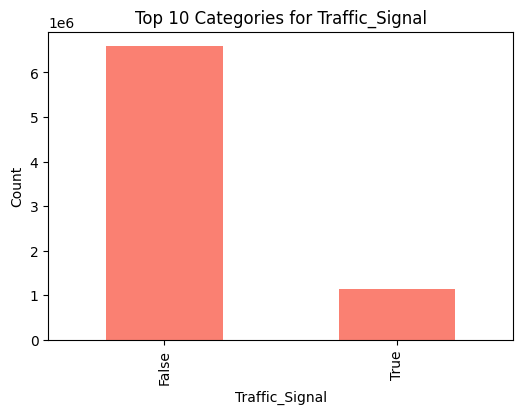

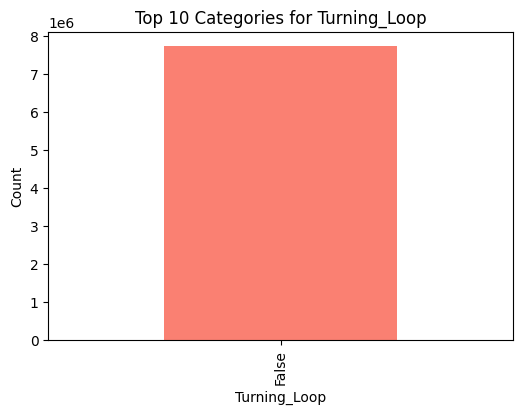

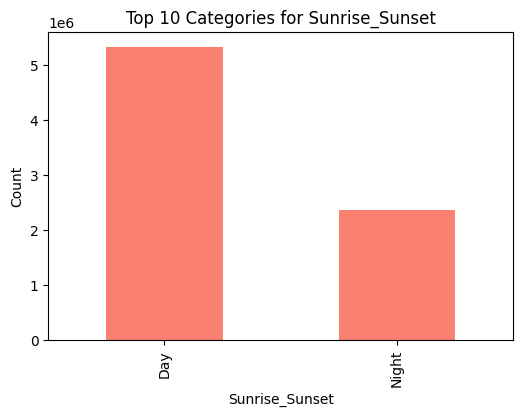

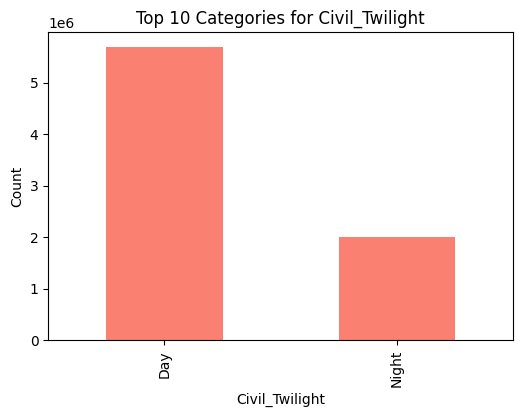

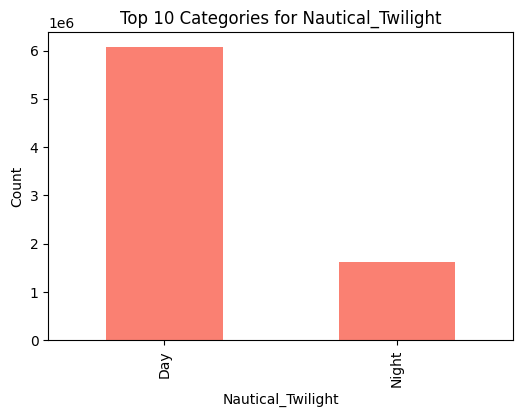

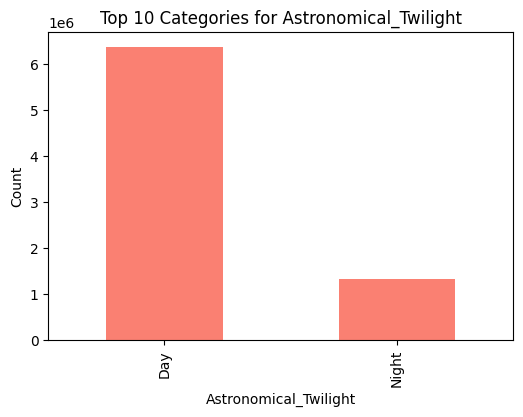

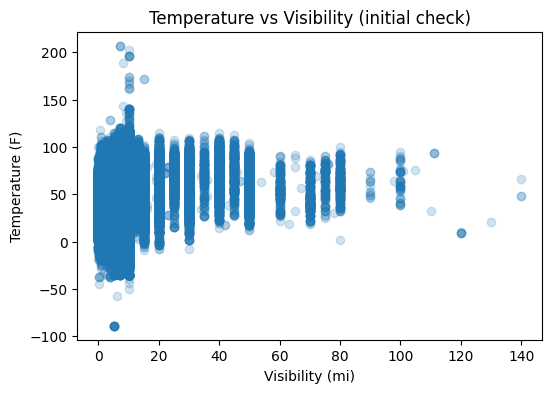

In [10]:
# Distribution of numeric columns

df[numerical_cols].hist(bins=30, figsize=(12,8), color='skyblue')
plt.suptitle("Distributions of Numeric Columns")
plt.show()

# Count of categorical columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().head(10).plot(kind='bar', color='salmon')
    plt.title(f"Top 10 Categories for {col}")
    plt.ylabel("Count")
    plt.show()

# Scatter plot for initial insights

plt.figure(figsize=(6,4))
plt.scatter(df["Visibility(mi)"], df["Temperature(F)"], alpha=0.2)
plt.xlabel("Visibility (mi)")
plt.ylabel("Temperature (F)")
plt.title("Temperature vs Visibility (initial check)")
plt.show()

## Data Preparation
Text here

This section explains how you cleaned and transformed the data before analysis.

Tasks:
- Handling missing values
- Filtering invalid values
- Removing outliers
- Converting data types (e.g., datetime)
- Creating new variables
- Feature engineering
- Subsetting columns
- Encoding categorical variables (if used)

Examples:
- Convert Start_Time to datetime
- Create Hour or DayOfWeek
- Remove unrealistic weather values
- Filter extreme wind speeds
- Example code actions you performed.

In [11]:
df.shape

(7728394, 46)

In [12]:
# Handle unnecessary columns


# Columns before drop
print("Columns before drop:", df.columns)

# Columns recommended to drop

cols_to_drop = [
    # Identifiers / free text
    "ID",               # unique record ID, not predictive
    "Description",      # long text, too unstructured for EDA
    "Street",           # high cardinality, not needed for analysis
    #"Number",           # street number, too granular
    "Airport_Code",     # rarely useful
    "Weather_Timestamp",# redundant if weather features exist
    "Country",           # all data is USA only
    
    ## Optional spatial columns (drop if not doing geospatial)
    #"City",             # keep if doing city-level analysis
    #"County",           # keep if doing county-level analysis
    #"Zipcode",          # high cardinality
    #"TimeZone",         # usually redundant with Sunrise_Sunset or Hour

    "Civil_Twilight",    # redundant with Sunrise_Sunset
    "Nautical_Twilight", # redundant with Sunrise_Sunset
    "Astronomical_Twilight" # redundant with Sunrise_Sunset
]

# Drop the columns from your working DataFrame
df = df.drop(columns=cols_to_drop)

# Quick check
print("Columns after drop:", df.columns)


#cols_to_drop = ["Description", "ID", "Street", "End_Time"]
#df = df.drop(columns=cols_to_drop)


Columns before drop: Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')
Columns after drop: Index(['Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'City', 'County',
       'State', 'Zipcode', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)',

In [13]:
df.shape

(7728394, 37)

In [20]:
#df["Sunrise_Sunset"]

In [14]:
# Convert data types and create new columns

# Convert datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")

# Create new features
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Duration_min"] = (pd.to_datetime(df["End_Time"]) - df["Start_Time"]).dt.total_seconds() / 60

In [15]:
df.shape

(7728394, 40)

In [16]:
df.isna().sum()

Source                     0
Severity                   0
Start_Time            743166
End_Time              743166
Start_Lat                  0
Start_Lng                  0
End_Lat              3402762
End_Lng              3402762
Distance(mi)               0
City                     253
County                     0
State                      0
Zipcode                 1915
Timezone                7808
Temperature(F)        163853
Wind_Chill(F)        1999019
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi)        177098
Wind_Direction        175206
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Weather_Condition     173459
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal

In [17]:
# Handle missing values

# Drop rows with missing severity
df = df.dropna(subset=["Start_Time",
                       "End_Time",
                       "City",
                       "Zipcode",
                       "Timezone",
                       "Temperature(F)",
                       #"Wind_Chill(F)",
                       "Humidity(%)",
                       "Pressure(in)",
                       "Visibility(mi)",
                       "Wind_Direction",
                       "Wind_Speed(mph)",
                       #"Precipitation(in)",
                       "Weather_Condition",
                       
                       "Sunrise_Sunset",

                       "Hour",
                       "DayOfWeek",
                       "Duration_min"
                      ])


## Fill missing numeric values with median
#numeric_cols = ["Temperature(F)", "Wind_Speed(mph)", "Visibility(mi)"]
#df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())



In [18]:
# Check that all NaN intended were removed
df.isna().sum()

# Note that NaN for columns End_Lat, End_Lng, Wind_Chill(F), and Precipitation(in) are kept because their number is too large.

Source                     0
Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
End_Lat              3008443
End_Lng              3008443
Distance(mi)               0
City                       0
County                     0
State                      0
Zipcode                    0
Timezone                   0
Temperature(F)             0
Wind_Chill(F)        1394049
Humidity(%)                0
Pressure(in)               0
Visibility(mi)             0
Wind_Direction             0
Wind_Speed(mph)            0
Precipitation(in)    1674273
Weather_Condition          0
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal

In [19]:
df.shape

(6353353, 40)

array([[<Axes: title={'center': 'Temperature(F)'}>,
        <Axes: title={'center': 'Visibility(mi)'}>],
       [<Axes: title={'center': 'Wind_Speed(mph)'}>, <Axes: >]],
      dtype=object)

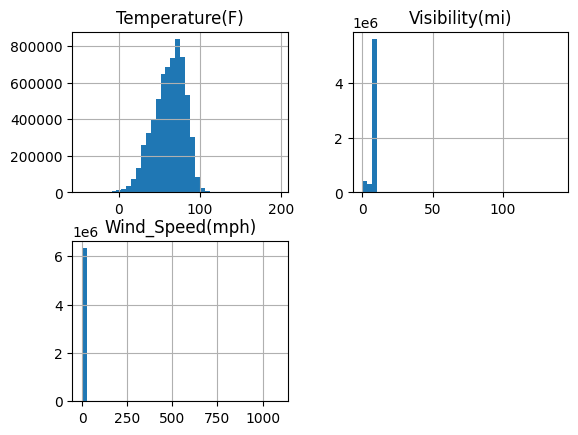

In [20]:
df[["Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)"]].hist(bins=40)

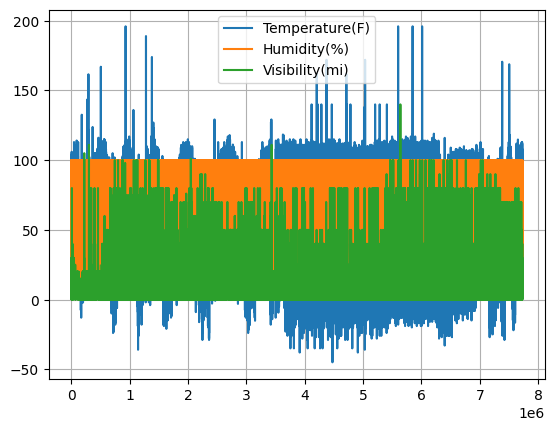

In [21]:
df[["Temperature(F)", "Humidity(%)", "Visibility(mi)"]].plot()
plt.grid(True)
plt.show()

In [22]:
weather_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df[weather_cols].agg(["min", "max", "mean", "median"])

,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in)
min,-45.000000,1.000000,0.000000,0.000000,0.000000
max,196.000000,100.000000,140.000000,1087.000000,36.470000
mean,61.912378,64.563052,9.111639,7.701469,0.008091
median,64.000000,67.000000,10.000000,7.000000,0.000000


In [23]:
df.select_dtypes(include="number").agg(["min", "max", "mean", "median"])

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour,DayOfWeek,Duration_min
min,1.000000,24.554800,-124.623833,24.566013,-124.545748,0.000000,-45.000000,-63.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+00
max,4.000000,49.002201,-67.113167,49.075000,-67.109242,441.750000,196.000000,196.000000,100.000000,58.630000,140.000000,1087.000000,36.470000,23.000000,6.000000,2.812939e+06
mean,2.219376,36.211696,-94.615152,36.276788,-96.011739,0.523172,61.912378,58.033899,64.563052,29.531741,9.111639,7.701469,0.008091,12.372976,2.574438,4.331650e+02
median,2.000000,35.813136,-87.826448,36.164428,-88.798887,0.010000,64.000000,62.000000,67.000000,29.850000,10.000000,7.000000,0.000000,13.000000,3.000000,7.061667e+01


In [24]:
# Handle outliers

# Keep realistic weather values
df = df[(df["Temperature(F)"].between(-40, 140)) &
        (df["Wind_Speed(mph)"].between(0, 100)) &
        (df["Visibility(mi)"].between(0, 20)) &
        (df["Humidity(%)"].between(0, 100))]

In [ ]:
# Final checks
# 
# Verify data types, ranges, missing values.
# Check distributions visually (histograms, boxplots) to confirm cleaning worked.
# Optionally, save the cleaned working copy for analysis.

In [25]:
# Engineered Features useful for Analysis

# Hour of Day
df["Hour"] = df["Start_Time"].dt.hour
df["RushHour"] = df["Hour"].isin([7,8,9,16,17,18])

# Day of Week / Weekend
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek  # 0=Monday, 6=Sunday
df["IsWeekend"] = df["DayOfWeek"] >= 5

# Day vs. Night
df["IsNight"] = df["Sunrise_Sunset"] == "Night"

# Bad Weather Indicator
df["BadWeather"] = (
    (df["Visibility(mi)"] < 2) |
    (df["Precipitation(in)"] > 0.2) |
    (df["Weather_Condition"].str.contains("Rain|Snow|Storm|Fog", na=False))
)

# Extreme Temperatures
df["ColdTemp"] = df["Temperature(F)"] < 32
df["HotTemp"] = df["Temperature(F)"] > 90

# Visibility Risk
df["LowVisibility"] = df["Visibility(mi)"] < 3

# Wind Risk
df["HighWind"] = df["Wind_Speed(mph)"] > 30

# Combined Road Risk Score
df["RoadRiskScore"] = (df[["Traffic_Signal", "Junction", "Crossing", "Stop", "Bump", "Amenity"]].sum(axis=1))



In [26]:
df.shape

(6344978, 49)

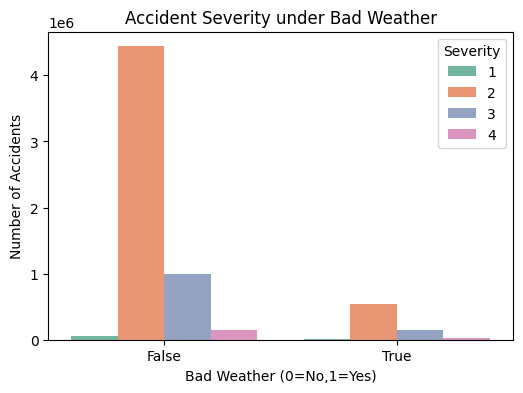

In [27]:
# Categorical Features vs. Target

plt.figure(figsize=(6,4))
sns.countplot(x="BadWeather", hue="Severity", data=df, palette="Set2")
plt.title("Accident Severity under Bad Weather")
plt.xlabel("Bad Weather (0=No,1=Yes)")
plt.ylabel("Number of Accidents")
plt.show()



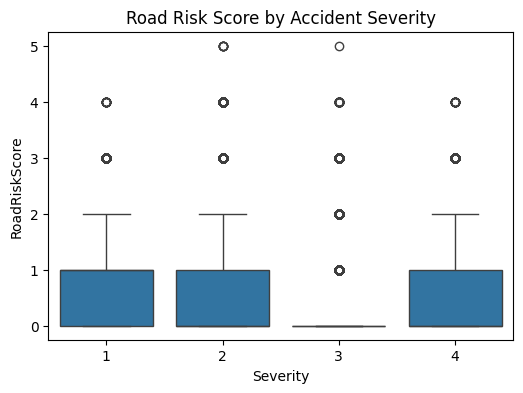

In [28]:
# Numeric Engineered Features vs. Target

plt.figure(figsize=(6,4))
sns.boxplot(x="Severity", y="RoadRiskScore", data=df)
plt.title("Road Risk Score by Accident Severity")
plt.show()

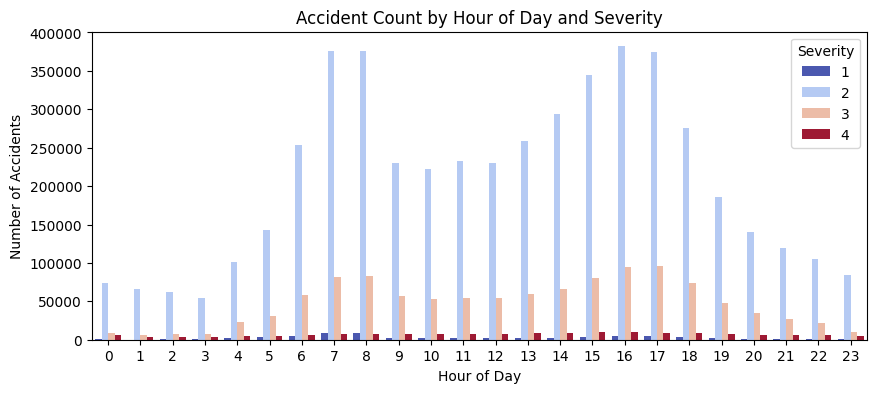

In [29]:
# Accidents by Hour

plt.figure(figsize=(10,4))
sns.countplot(x="Hour", hue="Severity", data=df, palette="coolwarm")
plt.title("Accident Count by Hour of Day and Severity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

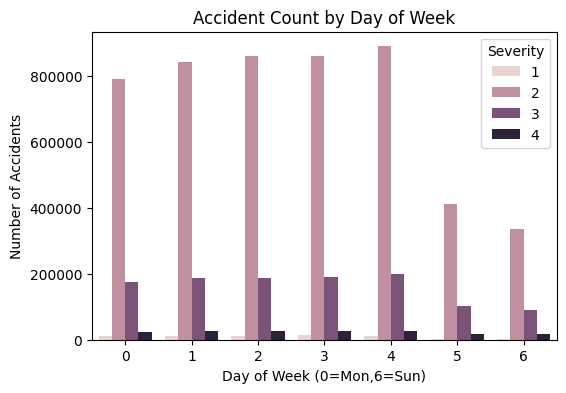

In [30]:
# Accidents by Day of Week

plt.figure(figsize=(6,4))
sns.countplot(x="DayOfWeek", hue="Severity", data=df)
plt.title("Accident Count by Day of Week")
plt.xlabel("Day of Week (0=Mon,6=Sun)")
plt.ylabel("Number of Accidents")
plt.show()

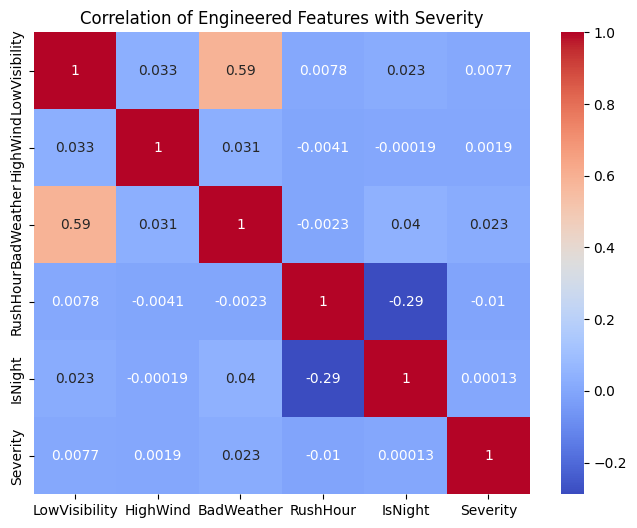

In [31]:
# Combine multiple Weather Features

features = ["LowVisibility", "HighWind", "BadWeather", "RushHour", "IsNight"]
corr = df[features + ["Severity"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Engineered Features with Severity")
plt.show()

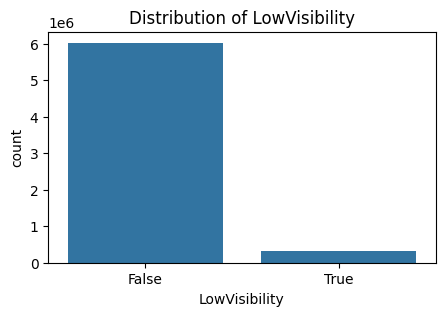

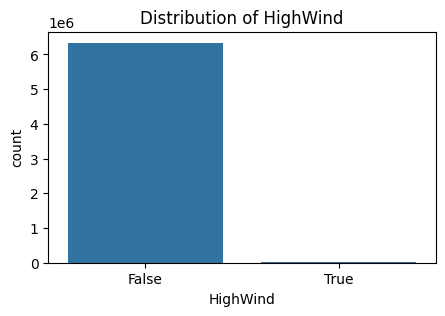

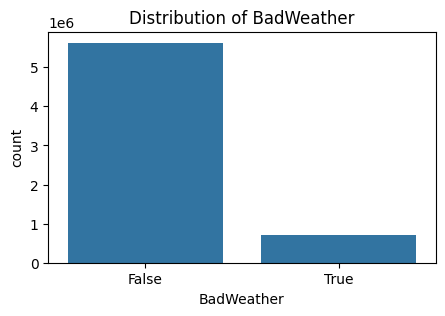

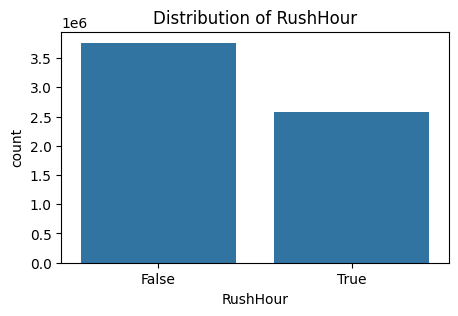

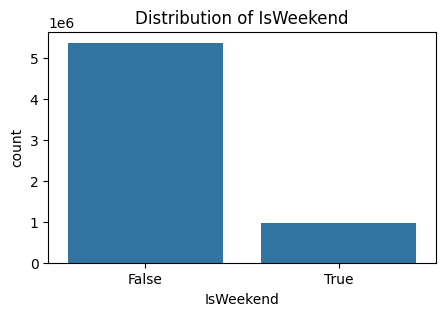

In [32]:
# Distribution of Engineered Features

for col in ["LowVisibility", "HighWind", "BadWeather", "RushHour", "IsWeekend"]:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

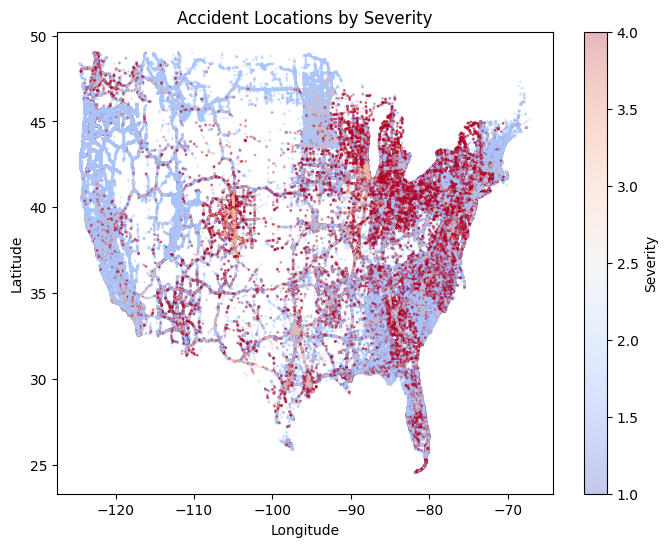

In [33]:
# Geographic Visualization

plt.figure(figsize=(8,6))
plt.scatter(df["Start_Lng"], df["Start_Lat"], s=1, c=df["Severity"], cmap="coolwarm", alpha=0.3)
plt.colorbar(label="Severity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Locations by Severity")
plt.show()

## Analysis

Text here

This is where you present the actual findings.

Include:

- Visualizations
- Statistical summaries
- Relationships between variables
- Answers to your analytical questions

Examples:
- Accident severity vs precipitation
- Day vs night accident comparison
- Weather conditions and accident frequency
- Geographic distribution of accidents
- Correlations between variables
- Explain what the plots mean.

## Evaluation

### Business Insight/Recommendation 1

### Business Insight/Recommendation 2

### Business Insight/Recommendation 3

### Tableau Dashboard link

## Conclusion and Next Steps
Text here